In [1]:
%pip install pandas scikit-learn imbalanced-learn matplotlib seaborn

   ---------------------------------------- 0.0/236.1 kB ? eta -:--:--
   ---------------------------------------- 0.0/236.1 kB ? eta -:--:--
   ----- ---------------------------------- 30.7/236.1 kB ? eta -:--:--
   ----- ---------------------------------- 30.7/236.1 kB ? eta -:--:--
   ------------------------ --------------- 143.4/236.1 kB 1.4 MB/s eta 0:00:01
   ---------------------------------------- 236.1/236.1 kB 1.8 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1단계 - 데이터 로드 및 기본 탐색

In [2]:
import pandas as pd

df = pd.read_csv('creditcard.csv')

print("shape:", df.shape)
df.head()

shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [4]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.175161e-15,3.384974e-16,-1.379537e-15,2.094852e-15,1.021879e-15,1.494498e-15,-5.620335e-16,1.149614e-16,-2.414189e-15,...,1.628620e-16,-3.576577e-16,2.618565e-16,4.473914e-15,5.109395e-16,1.686100e-15,-3.661401e-16,-1.227452e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [5]:
print("=== 건수 ===")
print(df['Class'].value_counts())

print("\n=== 비율 ===")
print(df['Class'].value_counts(normalize=True))

=== 건수 ===
Class
0    284315
1       492
Name: count, dtype: int64

=== 비율 ===
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


## 2단계 샘플링

In [6]:
# 사기 거래(Class=1)는 전부 유지
fraud = df[df['Class'] == 1]

# 정상 거래(Class=0)는 10,000건만 무작위 샘플링
normal = df[df['Class'] == 0].sample(n=10000, random_state=42)

# 두 데이터셋 합치기
df_sample = pd.concat([fraud, normal], axis=0)

print("샘플링 후 shape:", df_sample.shape)

샘플링 후 shape: (10492, 31)


In [7]:
# 샘플링 후 Class 비율 다시 확인
print("=== 건수 ===")
print(df_sample['Class'].value_counts())

print("\n=== 비율 ===")
print(df_sample['Class'].value_counts(normalize=True))


=== 건수 ===
Class
0    10000
1      492
Name: count, dtype: int64

=== 비율 ===
Class
0    0.953107
1    0.046893
Name: proportion, dtype: float64


## 3단계 데이터 전처리

In [8]:
from sklearn.preprocessing import StandardScaler

# Amount 표준화 → Amount_Scaled 생성
scaler = StandardScaler()
df_sample['Amount_Scaled'] = scaler.fit_transform(df_sample[['Amount']])

# 원본 Amount 제거
df_sample = df_sample.drop('Amount', axis=1)

df_sample.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Class,Amount_Scaled
541,406.0,-2.312227,1.951992,-1.609851,3.997906,-0.522188,-1.426545,-2.537387,1.391657,-2.770089,...,0.517232,-0.035049,-0.465211,0.320198,0.044519,0.177840,0.261145,-0.143276,1,-0.394650
623,472.0,-3.043541,-3.157307,1.088463,2.288644,1.359805,-1.064823,0.325574,-0.067794,-0.270953,...,0.661696,0.435477,1.375966,-0.293803,0.279798,-0.145362,-0.252773,0.035764,1,1.976514
4920,4462.0,-2.303350,1.759247,-0.359745,2.330243,-0.821628,-0.075788,0.562320,-0.399147,-0.238253,...,-0.294166,-0.932391,0.172726,-0.087330,-0.156114,-0.542628,0.039566,-0.153029,1,0.680800
6108,6986.0,-4.397974,1.358367,-2.592844,2.679787,-1.128131,-1.706536,-3.496197,-0.248778,-0.247768,...,0.573574,0.176968,-0.436207,-0.053502,0.252405,-0.657488,-0.827136,0.849573,1,-0.130191
6329,7519.0,1.234235,3.019740,-4.304597,4.732795,3.624201,-1.357746,1.713445,-0.496358,-1.282858,...,-0.379068,-0.704181,-0.656805,-1.632653,1.488901,0.566797,-0.010016,0.146793,1,-0.390168


In [9]:
# X, y 분리
X = df_sample.drop('Class', axis=1)
y = df_sample['Class']

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nX 컬럼:", list(X.columns))

X shape: (10492, 30)
y shape: (10492,)

X 컬럼: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount_Scaled']


## 4단계 - 학습/테스트 분할

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (8393, 30)
X_test shape: (2099, 30)


In [11]:
# 분할된 데이터의 Class 비율 출력
print("=== Train Class 비율 ===")
print(y_train.value_counts(normalize=True))
print("건수:")
print(y_train.value_counts())

print("\n=== Test Class 비율 ===")
print(y_test.value_counts(normalize=True))
print("건수:")
print(y_test.value_counts())

=== Train Class 비율 ===
Class
0    0.953056
1    0.046944
Name: proportion, dtype: float64
건수:
Class
0    7999
1     394
Name: count, dtype: int64

=== Test Class 비율 ===
Class
0    0.953311
1    0.046689
Name: proportion, dtype: float64
건수:
Class
0    2001
1      98
Name: count, dtype: int64


## 5단계 - SMOTE

In [12]:
from imblearn.over_sampling import SMOTE

# SMOTE 적용 전 사기 건수
print("=== SMOTE 적용 전 (Train) ===")
print(y_train.value_counts())

# SMOTE는 X_train에만 적용
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

# SMOTE 적용 후 사기 건수
print("\n=== SMOTE 적용 후 (Train) ===")
print(y_train_resampled.value_counts())

print("\nresampled shape:", X_train_resampled.shape)

=== SMOTE 적용 전 (Train) ===
Class
0    7999
1     394
Name: count, dtype: int64

=== SMOTE 적용 후 (Train) ===
Class
0    7999
1    7999
Name: count, dtype: int64

resampled shape: (15998, 30)


## 6단계 - 모델 학습

In [13]:
from sklearn.ensemble import RandomForestClassifier

# 모델 학습 (SMOTE로 증강한 train 데이터 사용)
model = RandomForestClassifier(random_state=42, n_jobs=-1)
model.fit(X_train_resampled, y_train_resampled)

# 테스트셋에서 예측 (원본 X_test 사용)
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]  # 사기(Class=1)일 확률

print("예측값 예시 (앞 20개):", y_pred[:20])
print("예측 확률 예시 (앞 10개):", y_proba[:10].round(3))

예측값 예시 (앞 20개): [0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0]
예측 확률 예시 (앞 10개): [0.02 0.   0.03 0.   0.18 0.   1.   0.   0.03 0.05]


In [14]:
from sklearn.metrics import classification_report, average_precision_score

# Precision, Recall, F1-score
print("=== Classification Report ===")
print(classification_report(y_test, y_pred, digits=4))

# PR-AUC
pr_auc = average_precision_score(y_test, y_proba)
print(f"PR-AUC: {pr_auc:.4f}")

=== Classification Report ===
              precision    recall  f1-score   support

           0     0.9945    0.9975    0.9960      2001
           1     0.9457    0.8878    0.9158        98

    accuracy                         0.9924      2099
   macro avg     0.9701    0.9426    0.9559      2099
weighted avg     0.9922    0.9924    0.9923      2099

PR-AUC: 0.9537


## 7단계 - Threshold 조정 해보기

In [15]:
from sklearn.metrics import precision_score, recall_score, f1_score

thresholds = [0.5, 0.4, 0.3, 0.2, 0.1]

print(f"{'Threshold':>10} {'Precision':>10} {'Recall':>10} {'F1':>10}")
print("-" * 42)
for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    p = precision_score(y_test, y_pred_t)
    r = recall_score(y_test, y_pred_t)
    f = f1_score(y_test, y_pred_t)
    print(f"{t:>10.1f} {p:>10.4f} {r:>10.4f} {f:>10.4f}")

 Threshold  Precision     Recall         F1
------------------------------------------
       0.5     0.9263     0.8980     0.9119
       0.4     0.8318     0.9082     0.8683
       0.3     0.7344     0.9592     0.8319
       0.2     0.5621     0.9694     0.7116
       0.1     0.3532     0.9694     0.5177


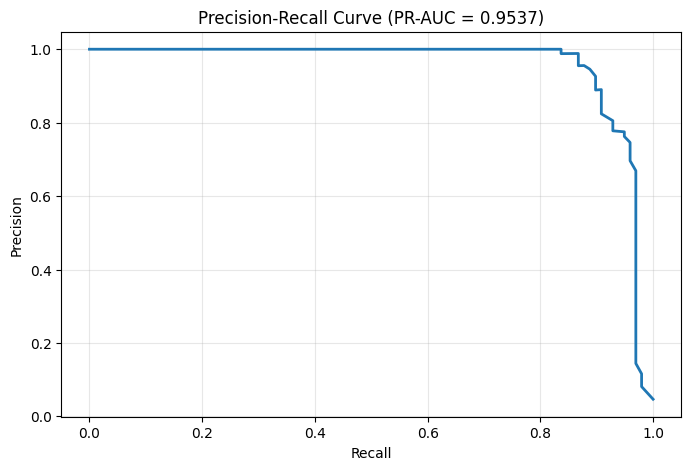

In [16]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

precisions, recalls, ths = precision_recall_curve(y_test, y_proba)

plt.figure(figsize=(8, 5))
plt.plot(recalls, precisions, linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve (PR-AUC = {pr_auc:.4f})')
plt.grid(True, alpha=0.3)
plt.savefig('pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()